In [13]:
import pandas as pd

df = pd.read_csv("Zoo.csv")

df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [3]:
df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

### Histogram

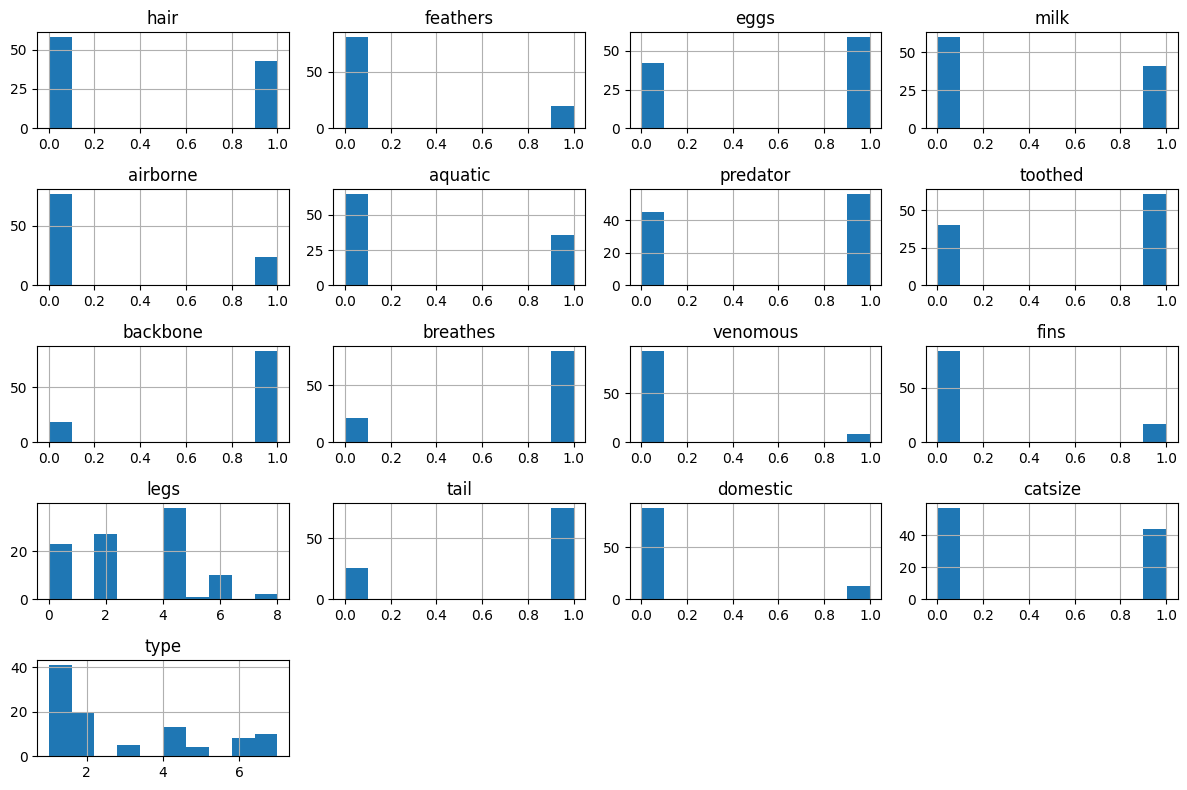

In [4]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()

### Boxplot (outliers check)

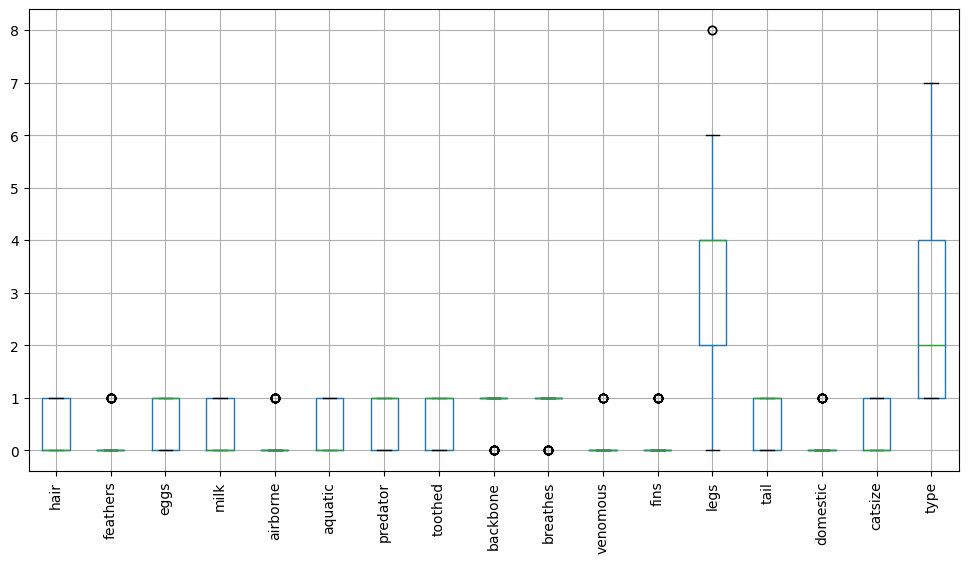

In [6]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))
plt.xticks(rotation=90)

plt.show()

### Scatter Plot

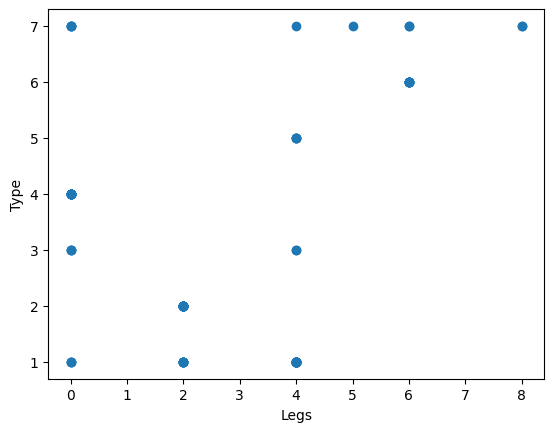

In [7]:
plt.scatter(df['legs'], df['type'])
plt.xlabel("Legs")
plt.ylabel("Type")

plt.show()

In [14]:
df = df.drop('animal name', axis=1)

### Features (X) aur Target (y) split

In [15]:
X = df.drop('type', axis=1)
y = df['type']

### Train-Test Split (80-20)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### KNN Model Training

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Prediction

In [18]:
y_pred = knn.predict(X_test)

### Model Evaluation
#### Accuracy, Precision, Recall, F1-score

In [19]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy
report

C:\Users\Akhlaque Alam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akhlaque Alam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akhlaque Alam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

'              precision    recall  f1-score   support\n\n           1       1.00      0.92      0.96        12\n           2       1.00      1.00      1.00         2\n           3       0.00      0.00      0.00         1\n           4       0.50      1.00      0.67         2\n           6       1.00      1.00      1.00         3\n           7       1.00      1.00      1.00         1\n\n    accuracy                           0.90        21\n   macro avg       0.75      0.82      0.77        21\nweighted avg       0.90      0.90      0.90        21\n'

### Decision Boundary Visualization

C:\Users\Akhlaque Alam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'KNN Decision Boundary')

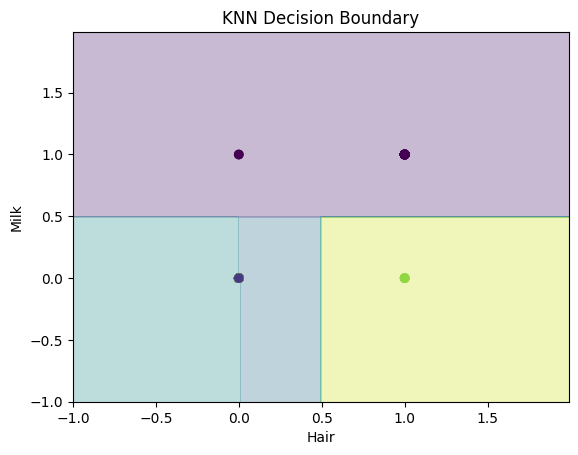

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# 2 features select (visualization ke liye)
X_vis = df[['hair', 'milk']]
y_vis = df['type']

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_vis, y_vis)

x_min, x_max = X_vis['hair'].min() - 1, X_vis['hair'].max() + 1
y_min, y_max = X_vis['milk'].min() - 1, X_vis['milk'].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis['hair'], X_vis['milk'], c=y_vis)
plt.xlabel("Hair")
plt.ylabel("Milk")
plt.title("KNN Decision Boundary")

# Interview Questions:

#### 1. What are the key hyperparameters in KNN?

##### Key Hyperparameters in KNN:

##### k (Number of Neighbors):
###### Number of nearest points used for prediction. Small k can overfit, large k can underfit.
##### Distance Metric:
###### Method to calculate distance (e.g., Euclidean, Manhattan). It decides how neighbors are selected.
##### Weighting Scheme:
###### Determines contribution of neighbors. Uniform gives equal weight; distance-based gives more weight to closer points.
##### Algorithm:
###### Method used to find neighbors (brute force, KD-tree, ball tree). Mainly affects speed.
##### Leaf Size:
###### Controls speed and memory in tree-based methods.

#### 2. What distance metrics can be used in KNN?

##### Distance metrics used in KNN:

##### Euclidean Distance:
###### Straight-line distance between two points (most commonly used).
##### Manhattan Distance:
###### Distance measured along axes (sum of absolute differences).
##### Minkowski Distance:
###### General form of Euclidean and Manhattan distance (based on a parameter p).
##### Hamming Distance:
###### Used for categorical/binary data; counts mismatches between values.
##### Cosine Distance:
###### Measures angle between vectors; useful in text and high-dimensional data.